<a href="https://colab.research.google.com/github/ThiagoDamasz/capacitacao-IA-CS-I/blob/main/Projeto_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importanto Bibliotecas

# Conectando meu drive ao Colab

Isso é feito para não precisar fazer o upload do Dataset sempre que eu abrir o notebook.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

Operações com o Dataset



In [4]:
#importando o Dataset (loan_risk_prediction)
caminho = "/content/drive/MyDrive/Notebooks_Capacitacao_IA/Datasets/loan_risk_prediction_dataset.csv"
df = pd.read_csv(caminho)

print("Cinco primeiras informações de cada coluna: \n")
print(df.head())
print("\n")

#Quantidade de linhas e colunas do dataset
print("Shape: \n")
print(df.shape)
print("\n")

#Tipos das colunas
print("Tipos das colunas: \n")
print(df.dtypes)

#Mostrando os valores ausentes de cada coluna no dataset
print("\n Valores ausentes: \n")
print(df.isna().sum())

#Apagando os campos ausentes para não atrapalhar na análise
df = df.dropna()

#Retirando os dados negativos da coluna Income e Loan amount
df = df[df['Income'] >= 0]
df = df[df['LoanAmount'] >= 0]

#Mostrando as estatísticas das colunas numéricas
print("\n Estatísticas das colunas numéricas: \n")
print(df.describe())



Cinco primeiras informações de cada coluna: 

   Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  \
0   56  48353.0     31258.0        675.0               20  Female   
1   69  57462.0     23262.0        586.0                6    Male   
2   46  44219.0     26530.0        781.0               26    Male   
3   32  56307.0     11531.0        549.0               11    Male   
4   60  37034.0     27871.0        500.0               19  Female   

     Education           City EmploymentType  LoanApproved  
0  High School        Houston     Unemployed             0  
1  High School  San Francisco  Self-Employed             0  
2          PhD        Houston  Self-Employed             1  
3          NaN       New York     Unemployed             0  
4  High School        Chicago     Unemployed             0  


Shape: 

(5000, 10)


Tipos das colunas: 

Age                  int64
Income             float64
LoanAmount         float64
CreditScore        float64
YearsExperience     

# Pré-processamento Avançado.

# Seleção de features

Esse processo aprofundado do EDA se consiste em escolher as variáveis (colunas) que realmente vão ser utilizadas no modelo IA.

O método que vou usar é o método de correlação, quando procuro quais variáveis se relacionam entre si e podem ser mais relevantes.

**Como ler o resultado:** Valores vão de 1 a -1. Quanto mais próximos de 0 menor será a relação. Se proxímo de "1" a relação é forte positiva, caso próximo de "-1" a relação é forte negativa.


In [9]:
# Matriz de correlação
correlacao = df.corr(numeric_only=True)

print(correlacao)



                      Age    Income  LoanAmount  CreditScore  YearsExperience  \
Age              1.000000 -0.004158   -0.012669     0.000803        -0.020798   
Income          -0.004158  1.000000    0.001436    -0.051877        -0.010836   
LoanAmount      -0.012669  0.001436    1.000000     0.008536         0.008810   
CreditScore      0.000803 -0.051877    0.008536     1.000000        -0.001867   
YearsExperience -0.020798 -0.010836    0.008810    -0.001867         1.000000   
LoanApproved    -0.010452  0.199622    0.017560     0.461239        -0.011207   

                 LoanApproved  
Age                 -0.010452  
Income               0.199622  
LoanAmount           0.017560  
CreditScore          0.461239  
YearsExperience     -0.011207  
LoanApproved         1.000000  


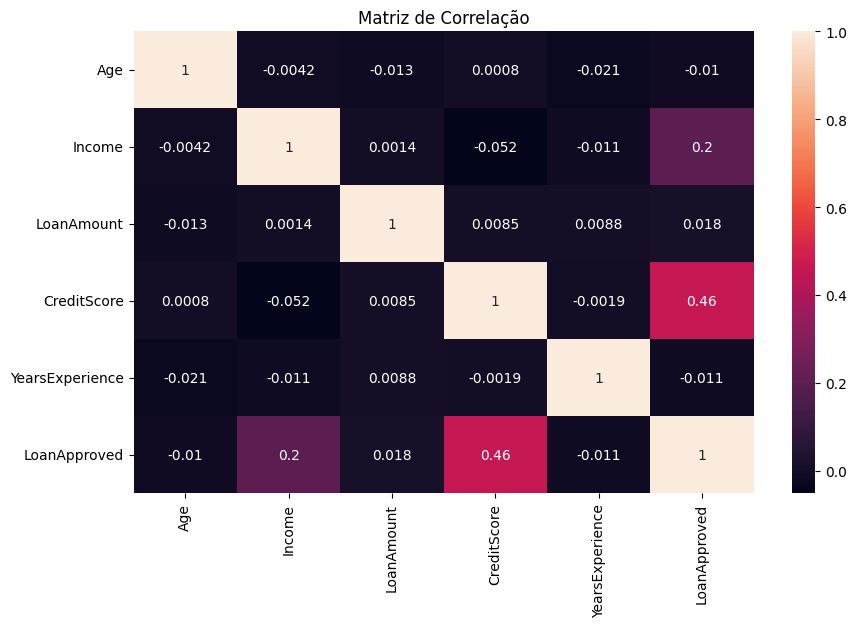

In [10]:
plt.figure(figsize=(10,6))

sns.heatmap(correlacao, annot=True)

plt.title("Matriz de Correlação")
plt.show()

Estamos analisando a coluna **loanAproved** que é a principal para o modelo.

Pelos resultados é possível chegar a essas conclusões:

*   A maior relação com loanAproved é CreditScore, com 0.46 a maior de todas.
*   Existe relação com a coluna Income, porém é menor.
*   O restante dos resultados deu bem próximo de 0, isso significa que não temos uma relação significativa.





# Escalonamento

É o processo de transformar os dados numéricos na mesma escala para evitar de confundir o modelo. Isto é "Age = dezenas", "Income = milhares" etc. Trazer as unidades para a mesma escala.

O processo que irei utilizar é a **padronização**, que é mais utilizada em projetos de ML. O mesmo se consiste em transformar a média em 0 e o desvio padrão em 1.

Isso centraliza os dados e deixa tudo comparável. Também mantém os outliers.



In [12]:
# Selecionando as variáveis que vão ser padronizadas.
colunas_numericas = ['Income','CreditScore']

In [14]:
#aprender a escala dos dados e aplicar padronização.
scaler = StandardScaler()

#fit_transform aplica média e desvio padrão e faz a transformação.
df[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])

In [15]:
print(df[colunas_numericas].describe())

             Income   CreditScore
count  4.401000e+03  4.401000e+03
mean   2.324884e-16 -1.323892e-16
std    1.000114e+00  1.000114e+00
min   -3.302398e+00 -1.719152e+00
25%   -6.667385e-01 -8.851582e-01
50%   -1.846488e-02  2.352218e-02
75%    6.732401e-01  8.512926e-01
max    3.293379e+00  1.697735e+00


Após aplicar o escalonamento podemos ver que a média está próxima de 0, e o desvio padrão próximo de 1. Isso significa que foi feito corretamente na medida do possível.

# Dividindo os Dados em train/test

Nessa etapa eu dividi os dados em dados de treino e dados de teste. Isso é feito para decidir os dados que irão para o modelo como teste e que serão usados para o treinamento.

Essa escolha foi feita baseado na **Seleção das features** e do **escalonamento**, onde defini as features mais importantes do dataset.



In [20]:
X = df[['Income', 'CreditScore']]  # features
y = df['LoanApproved']             # target

#20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42 # garante que retornará o mesmo resultado
)

print(X_train.shape)
print(X_test.shape)

(3520, 2)
(881, 2)


# Pipeline

É uma forma de organizar todas as etapas do modelo em um fluxo automático.

Uma pipeline executa etapas em sequência Ex: padronização -> Modelo de classificação.

**Columntransformer**

Ferramenta que permite aplicar transformações diferentes para colunas diferentes.

In [38]:
#Definindo as colunas
colunas_numericas = ['Income', 'CreditScore']

#CriandoColumns
preprocessador = ColumnTransformer([
    ('num', StandardScaler(), colunas_numericas)
])



O quê eu fiz acima foi basicamente automatizar a etapa de escalonamento, que eu tinha feito manualmente antes utilizando o Columntransformer.

In [39]:
#criando a pipeline com logistic regression
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression())
])

#criando pipeline com árvore de decisão
pipeline_arvoredecisao = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', DecisionTreeClassifier())
])

#criando pipeline com random forest
pipeline_rf = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', RandomForestClassifier())
])


**Treinamento**

É nesse momento que iremos executar os modelos escolhidos. No meu caso serão logistic regression, random_forest e decision_tree.


In [40]:
#Treinando os modelos
pipeline_lr.fit(X_train, y_train)
pipeline_arvoredecisao.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Income', 'CreditScore'])])),
                ('modelo', RandomForestClassifier())])

In [42]:
#Fazendo as previsões
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_arvoredecisao = pipeline_arvoredecisao.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

**GridSearch**

Abaixo irei implementar o gridSearch em uma nova pipeline. Escolhendo os **hiperparametros**. Vou usar o modelo da árvore de decisão.

In [44]:
#Definindo hiperparametros
parametros = {
    'modelo__max_depth': [3, 5, 10],
    'modelo__min_samples_split': [2, 5, 10]
}

#Criando o gridSearch
grid = GridSearchCV(
    pipeline_arvoredecisao,
    parametros,
    cv=5
)

#treinando
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessamento',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Income',
                                                                          'CreditScore'])])),
                                       ('modelo', DecisionTreeClassifier())]),
             param_grid={'modelo__max_depth': [3, 5, 10],
                         'modelo__min_samples_split': [2, 5, 10]})

In [46]:
#Resultados
print(grid.best_params_)
print(grid.best_score_)

{'modelo__max_depth': 3, 'modelo__min_samples_split': 10}
0.8610795454545455


Acima podemos ver os resultados **"max_depth = 3"** e **"min_samples_split = 10"**. Isso significa que essa foi a melhor configuração do modelo.

O segundo resultado **0.8610795454545455** é o desempenho durante o processo de busca.

# Gráficos



Aqui vou pegar os gráficos baseados no melhor modelo que encontrei. Seria aquele que usei o **GridSearch**. Então usarei apenas aquela pipeline, as outras que fiz antes estavam apenas cumprindo os critérios necessários para o envio das atividades.

In [47]:
best_model = grid.best_estimator_

Matriz De Confusão

As linhas representam os valores reais (true label) e as colunas representam as previsões do modelo (predicted label). A diagonal principal indica os acertos do modelo, enquanto os demais valores representam os erros, divididos em falsos positivos e falsos negativos.

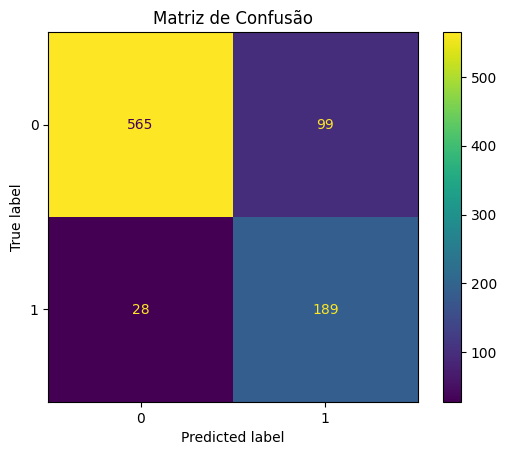

In [50]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matriz de Confusão")
plt.show()

Relatório de Classificação

O relatório de classificação apresenta métricas importantes para avaliar o desempenho do modelo, como precision, recall e f1-score. A precision indica a proporção de previsões corretas, o recall mostra a capacidade do modelo de identificar corretamente os casos positivos, e o f1-score é uma média entre essas duas métricas.

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.85      0.90       664
           1       0.66      0.87      0.75       217

    accuracy                           0.86       881
   macro avg       0.80      0.86      0.82       881
weighted avg       0.88      0.86      0.86       881



Curva ROC

A curva ROC é utilizada para avaliar a capacidade do modelo em distinguir entre as classes. Ela relaciona a taxa de verdadeiros positivos (TPR) com a taxa de falsos positivos (FPR) em diferentes limiares de decisão. Quanto mais próxima a curva estiver do canto superior esquerdo, melhor o desempenho do modelo. O valor da AUC (área sob a curva) resume essa performance, sendo que valores próximos de 1 indicam um modelo mais eficaz.

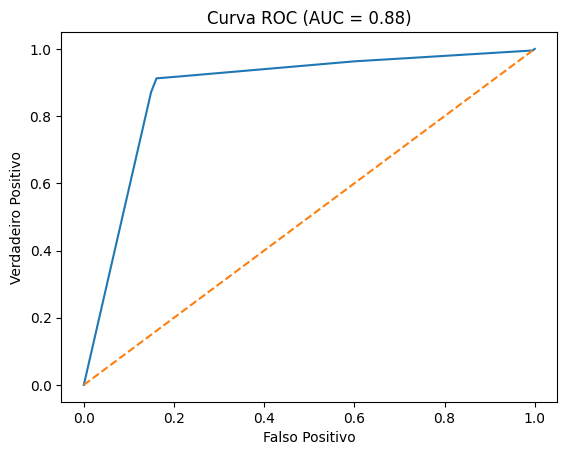

In [55]:
y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("Falso Positivo")
plt.ylabel("Verdadeiro Positivo")
plt.title(f"Curva ROC (AUC = {roc_auc:.2f})")

plt.show()